# Exercise potential energy statically indeterminate structure

Find the displacement in C using potential energy.

```{figure} figures/structure.svg
---
name: structure
---

Structure
```

Let's start by defining the trial function. Let's assume a parabolic displacement field with the shape $u\left(x\right) = a + b x + c$.

```{exercise} Boundary conditions kinematical admissible trial function
:label: exercise_1
:nonumber: true

The displacement field must be kinematically admissible. Which boundary conditions must be enforced for that?
```

```{solution} exercise_1
:class: dropdown

- $u\left(0\right) = 0$
- $u\left(L\right) = 0$
```

```{exercise-start} Kinematical admissibility trial function
:label: exercise_2
:nonumber: true

Now, let's use SymPy to rewrite the trial function so that it is kinematically admissible.
```

In [ ]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [ ]:
u_trial_general = a + b * x + c * x **2

eq1 = sym.Eq(u_trial_general.subs(x, #value to substitute for x), #right hand side of equation)
eq2 = #...
sol = sym.solve((eq1,eq2),(a,b))
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

Let's check your solution graphically for a value of $1$ for $c$ and $5$ for $L$:

In [55]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_formats = ['svg']

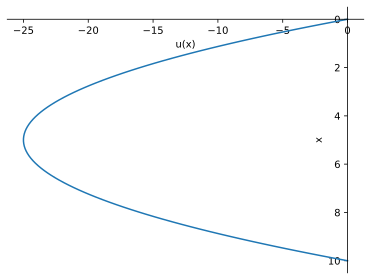

In [60]:
u_trial_func = sym.lambdify(x, u_trial.subs(sol).subs(c,1).subs(L,5))
x_plot = np.linspace(0, 10,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
ax.invert_yaxis()


It should match your boundary conditions of [](exercise_1)

```{exercise-end}
```

```{solution-start} exercise_2
:class: dropdown
```

In [22]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [34]:
u_trial_general = a+b*x+c*x**2

eq1 = sym.Eq(u_trial_general.subs(x,0), 0)
eq2 = sym.Eq(u_trial_general.subs(x,2*L), 0)
sol = sym.solve((eq1,eq2),[a,b])
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

{a: 0, b: -2*L*c}

-2*L*c*x + c*x**2

```{solution-end}
```

For the strain energy we needed the strain distribution instead of the displacement. The strain is the derivative of the displacement, which can be found with SymPy:

In [61]:
epsilon = sym.diff(u_trial,x)
display(epsilon)

-2*L*c + 2*c*x